<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_python_programming/blob/main/practices/Practica_22_Ejercicios_de_Normalizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importar librerías

In [ ]:
import sklearn
import numpy as np
from scipy import stats
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def shapiro_test(datos_antes):
  alpha = 0.05
  statistic, p_value = stats.shapiro(datos_antes, axis=0)
  print(f"Estadístico de prueba: {statistic}")
  print(f"Valor p: {p_value}")
  if p_value > alpha:
    print("No se rechaza la hipótesis nula: los datos son normales.\n")
  else:
    print("Se rechaza la hipótesis nula: los datos no son normales.\n")

In [ ]:
def graficar_antes_despues(metodo, datos_antes, datos_despues, variable, bins=10):
  fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
  sns.histplot(datos_antes, kde=True, bins=bins, edgecolor='black', ax=axs[0])
  axs[0].set_title(f"datos antes de escalar con {metodo}")
  axs[0].set_xlabel(f"{variable}")
  axs[0].set_ylabel('Frecuencia')

  # Crear el QQ plot
  sns.histplot(datos_despues, kde=True, bins=bins, edgecolor='black', ax=axs[1])
  axs[1].set_title(f"datos después de escalar con {metodo}")
  axs[1].set_xlabel(f"{variable}")
  axs[1].set_ylabel('Frecuencia')

  fig.suptitle(f"{variable}")
  plt.tight_layout()
  plt.show()


# Ejercicio 1: Normalización Min-Max

1.	Cargar el dataset wine de sklearn.
2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?<br>
    * **El escalador Min-Max, toma el dato minimo y maximo de la variable alcohol, a partir de eso escala los datos entre el rango 0-1, 1 siendo el 0 el valor mínimo y 1 el valor máximo.**
2. ¿Qué interpretas del p-valor antes y después de la normalización?
    * **Dado que este metodo, sólo convierte la escala de su rango original a un rango entre 0 y 1, la distribución no cambia por lo tanto, la prueba estadística tampoco cambiará, como se muestra en la gráfica.**


In [ ]:
# 1. Cargar el dataset wine de sklearn
wine = load_wine(as_frame=True)
wine_df = wine.frame
wine_df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [ ]:
# 2. Seleccionar una de las características numéricas (por ejemplo, alcohol).
variable = 'alcohol'
datos_antes = wine_df[[variable]]

In [ ]:
# 3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
### Hipotesis Nula: Los datos son normalmente distribuidos
### Hipotesis Alterna: Los datos no son normalmente distribuidos
shapiro_test(datos_antes)

Estadístico de prueba: [0.98180414]
Valor p: [0.02004798]
Se rechaza la hipótesis nula: los datos no son normales.



In [ ]:
# 4. Aplicar la normalización Min-Max a los datos seleccionados.
minn, maxx = datos_antes.min(), datos_antes.max()
print(minn, maxx)
datos_despues = MinMaxScaler().fit_transform(datos_antes)

alcohol    11.03
dtype: float64 alcohol    14.83
dtype: float64


In [ ]:
# 5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
shapiro_test(datos_despues)

Estadístico de prueba: [0.98180414]
Valor p: [0.02004798]
Se rechaza la hipótesis nula: los datos no son normales.



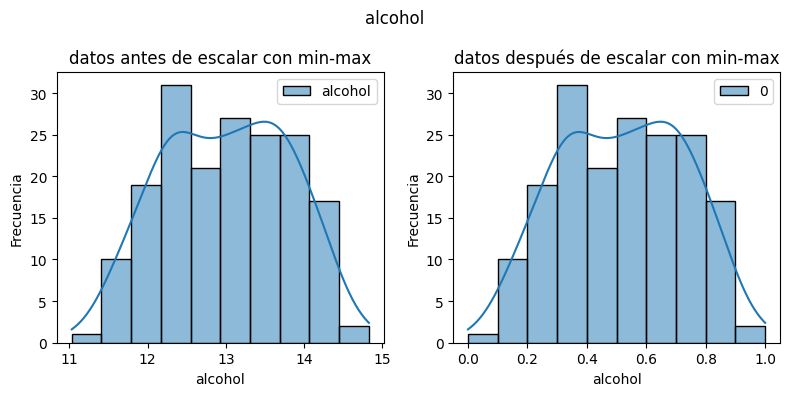

In [ ]:
# 6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
graficar_antes_despues('min-max', datos_antes, datos_despues, variable)

# Ejercicio 2: Normalización Z-Score

1.	Cargar el dataset wine de sklearn.
2.	Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Z-Score a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.


Preguntas:

1.	¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
    * **Los datos originales de la variable alcohol, tenian la media en 13.000168, mientras que la media en los datos normalizados con z-score, es 0.**
2.	¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?
    * **Podría ayudarnos a estandarizar distintas caracteristicas que podrian no estar en la misma magnitud, después de aplicada las variables compartirían la misma escala.**

Estadístico de prueba: [0.98180414]
Valor p: [0.02004798]
Se rechaza la hipótesis nula: los datos no son normales.

alcohol    13.000618
dtype: float64
alcohol    0.809543
dtype: float64
Estadístico de prueba: [0.98180414]
Valor p: [0.02004798]
Se rechaza la hipótesis nula: los datos no son normales.



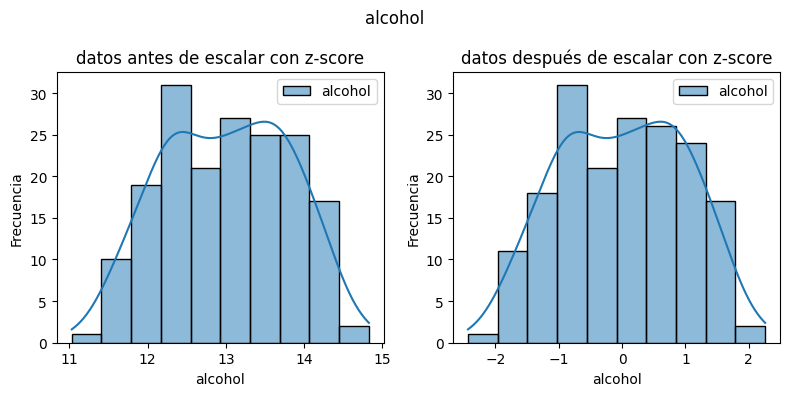

In [ ]:
# 1. Cargar el dataset wine de sklearn.
wine = load_wine(as_frame=True)
wine_df = wine.frame
# 2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
datos_antes = wine_df[[variable]]

# 3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
### Hipotesis Nula: Los datos son normalmente distribuidos
### Hipotesis Alterna: Los datos no son normalmente distribuidos
shapiro_test(datos_antes)

# 4. Aplicar la normalización Z-Score a los datos seleccionados.
mean = np.mean(datos_antes, axis=0)
print(mean)
std = np.std(datos_antes, axis=0)
print(std)
datos_despues = (datos_antes - mean) / std

# 5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
shapiro_test(datos_despues)

# 6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
graficar_antes_despues('z-score', datos_antes, datos_despues, variable)

# Ejercicio 3: Transformación Logarítmica

1.	Cargar un conjunto de datos aleatorios generados con numpy.
2.	Aplicar una transformación logarítmica (np.log) a los datos.
3.	Realizar una prueba de normalidad sobre los datos originales y transformados.
4.	Graficar los datos originales y transformados utilizando matplotlib.
5.	Responder las preguntas siguientes.

Preguntas:

1.	¿Cómo afectó la transformación logarítmica a la distribución de los datos?
    * **Cambio la escala de la variable "alcohol", también basado en la histograma, diría que hizo la distribución parecer más uniforme, al menos en el area central de la distribución.**
2.	¿Qué interpretas del p-valor antes y después de la transformación logarítmica?
    * **El valor p decayó después de aplicar la transformación logarítmica ~0.007, lo que podría indicar que los datos son más uniformes después de la transformación, y menos normal.**

Estadístico de prueba: [0.98180414]
Valor p: [0.02004798]
Se rechaza la hipótesis nula: los datos no son normales.

Estadístico de prueba: [0.98037489]
Valor p: [0.01301677]
Se rechaza la hipótesis nula: los datos no son normales.



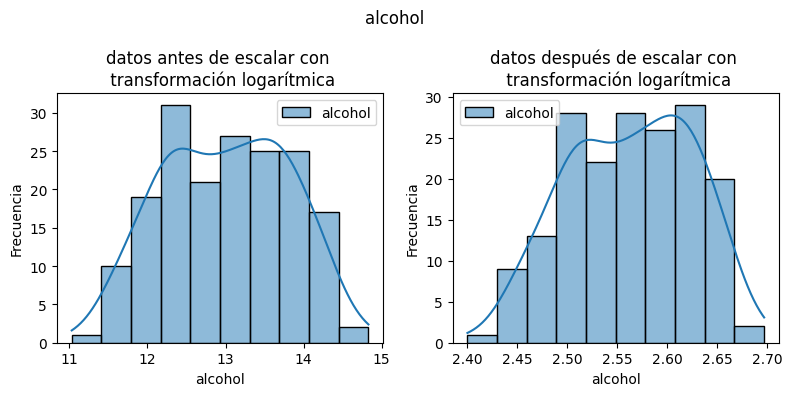

In [ ]:
# 1. Cargar el dataset wine de sklearn.
wine = load_wine(as_frame=True)
wine_df = wine.frame
# 2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
datos_antes = wine_df[[variable]]

# 3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
### Hipotesis Nula: Los datos son normalmente distribuidos
### Hipotesis Alterna: Los datos no son normalmente distribuidos
shapiro_test(datos_antes)

# 4. Aplicar la transformación logarítmica a los datos seleccionados.
datos_despues = np.log(datos_antes)

# 5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
shapiro_test(datos_despues)

# 6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
graficar_antes_despues('\n transformación logarítmica', datos_antes, datos_despues, variable)

# Ejercicio 4: Transformación Raíz Cuadrada

1.	Cargar un conjunto de datos aleatorios generados con numpy.
2.	Aplicar una transformación de raíz cuadrada a los datos.
3.	Realizar una prueba de normalidad sobre los datos originales y transformados.
4.	Graficar los datos originales y transformados utilizando matplotlib.
5.	Responder las preguntas siguientes.

Preguntas:

1.	¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
    * **Cambio la escala de los datos y la distribución original que estaba sesgada a la derecha, a parecerse más a una distribución mas normal, escalando outliers**
2.	¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?
    * **Hace que los datos grandes sean mas pequeños y los datos pequeños sean mas grandes.**

In [ ]:
import math
# 1. Cargar un conjunto de datos aleatorios generados con numpy.
np.random.seed(42)
datos_antes = np.random.exponential(scale=3.45, size=1000)
print(datos_antes.max())
print(datos_antes.min())
# 2. Aplicar una transformación de raíz cuadrada a los datos.
datos_despues = np.sqrt(datos_antes)
print(datos_despues.max())
print(datos_despues.min())
# 3. Realizar una prueba de normalidad sobre los datos originales y transformados.
shapiro_test(datos_antes)

shapiro_test(datos_despues)

28.194937312472387
0.016017605028882952
5.309890517936541
0.12656067726147388
Estadístico de prueba: 0.8246251308106578
Valor p: 1.094865579608503e-31
Se rechaza la hipótesis nula: los datos no son normales.

Estadístico de prueba: 0.969923940106859
Valor p: 1.577931524350108e-13
Se rechaza la hipótesis nula: los datos no son normales.



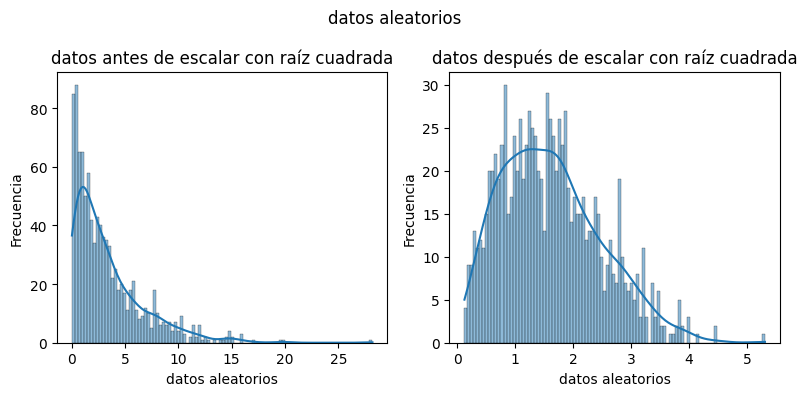

In [ ]:
# 4. Graficar los datos originales y transformados utilizando matplotlib.
graficar_antes_despues('raíz cuadrada', datos_antes, datos_despues, 'datos aleatorios', 100)

# Ejercicio 5: Transformación Box-Cox

1.	Cargar un conjunto de datos aleatorios generados con numpy.
2.	Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3.	Realizar una prueba de normalidad sobre los datos originales y transformados.
4.	Graficar los datos originales y transformados utilizando matplotlib.
5.	Responder las preguntas siguientes.

Preguntas:

1.	¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
    * **Hizo que los datos pasarán de su forma exponencial, a una distribucón que se asemeja mas a una distribución normal, y eso se refleja en el valor de p, despues de aplicar la transformacion pasando de 1.094e-31 a 0.00367.**
2.	¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?
    * **A diferentes valores de lambda, distintas transformaciones suceden, desde solo cambiar la escala, agrupar los valores hacia el otro extremo o aplicar una transformación logarítmica.**


In [ ]:
# 1. Cargar un conjunto de datos aleatorios generados con numpy.
np.random.seed(42)
datos_antes = np.random.exponential(size=1000)

# 2. Aplicar una transformación de raíz cuadrada a los datos.
datos_despues, l = stats.boxcox(datos_antes)
print(l)
# 3. Realizar una prueba de normalidad sobre los datos originales y transformados.
shapiro_test(datos_antes)

shapiro_test(datos_despues)

0.24618453123713666
Estadístico de prueba: 0.8246251308106578
Valor p: 1.094865579608503e-31
Se rechaza la hipótesis nula: los datos no son normales.

Estadístico de prueba: 0.9953205015296642
Valor p: 0.003679984624040763
Se rechaza la hipótesis nula: los datos no son normales.



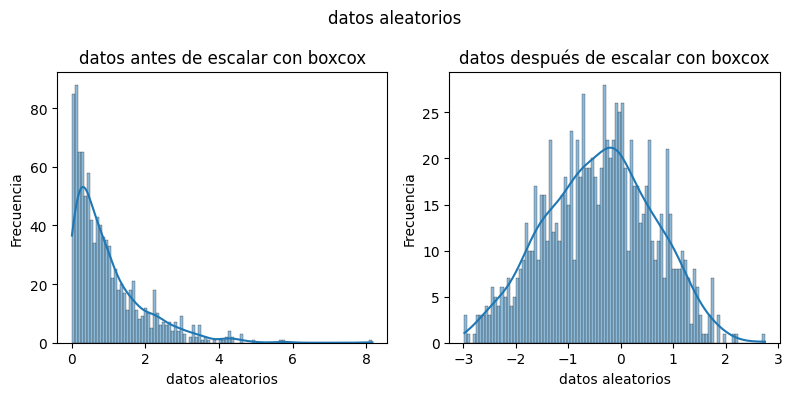

In [ ]:
# 4. Graficar los datos originales y transformados utilizando matplotlib.
graficar_antes_despues('boxcox', datos_antes, datos_despues, 'datos aleatorios', 100)